In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

In [2]:
tree = DecisionTreeClassifier()

In [3]:
# Модель для классификации с энтропиейб по умолчанию Джини
tree_classif = DecisionTreeClassifier(criterion='entropy')

# Модель для регрессиии с МАЕ, занчение по умолчанию - 'squared_error', дисперси
tree_regress = DecisionTreeRegressor(criterion='absolute_error')

In [4]:
# Создаём синтетические данные
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Функция для визуализации границы решения
def visualize_decision_boundary(tree, X_train, X_test, y_train, y_test, max_depth):
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap="RdYlBu")
    ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
               c="red", marker="o", s=50, alpha=0.7, label="Класс 0 (обучение)")
    ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
               c="blue", marker="s", s=50, alpha=0.7, label="Класс 1 (обучение)")
    ax.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1],
               c="red", marker="^", s=100, alpha=0.9, label="Класс 0 (тест)")
    ax.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
               c="blue", marker="v", s=100, alpha=0.9, label="Класс 1 (тест)")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"Граница решения (max_depth={max_depth})")
    ax.legend()
    ax.set_xlabel("Признак 1")
    ax.set_ylabel("Признак 2")
    plt.tight_layout()
    plt.show() 

In [5]:
# =======Значения для эксперимента=======
max_depth = 3

# обучение дерево
tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
tree.fit(X_train, y_train)

# Предсказания и метрики
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Глубина дерева: {max_depth}")
print(f"Точность на обучении: {train_accuracy:.3f}")
print(f"Точность на тесте: {test_accuracy:.3f}")
print(f"Разность (переобучение): {train_accuracy - test_accuracy:.3f}")
print(f"Количество узлов: {tree.tree_.node_count}")
print(f"Количество листьев: {tree.tree_.n_leaves}")

Глубина дерева: 3
Точность на обучении: 0.914
Точность на тесте: 0.922
Разность (переобучение): -0.008
Количество узлов: 11
Количество листьев: 6


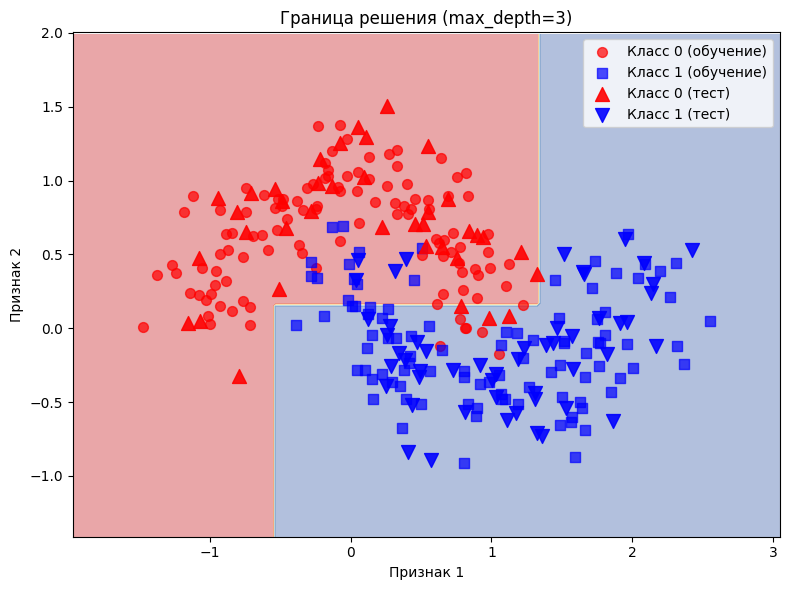

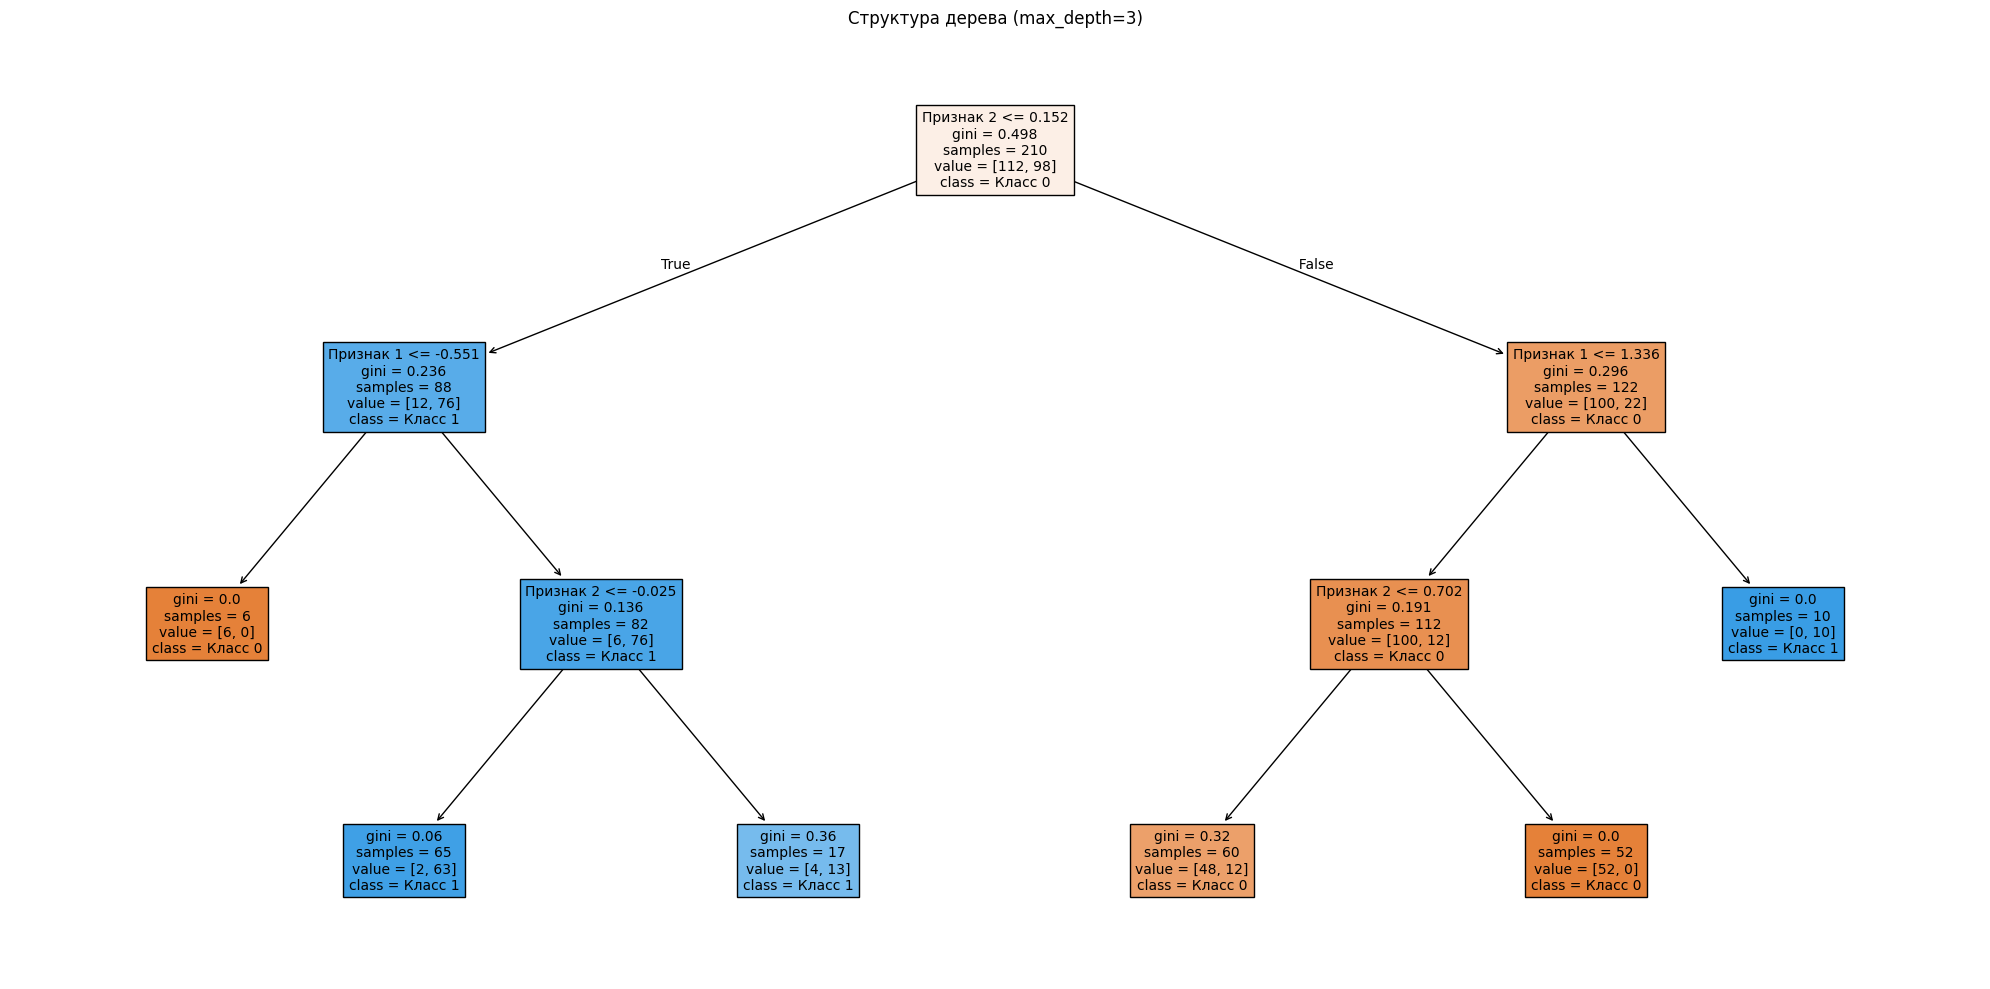

In [6]:
# Визуализация
visualize_decision_boundary(tree, X_train, X_test, y_train, y_test, max_depth)

# Дерево решений
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
plot_tree(tree, ax=ax, filled=True,
          feature_names=['Признак 1', 'Признак 2'],
          class_names=["Класс 0", "Класс 1"], fontsize=10)
ax.set_title(f"Структура дерева (max_depth={max_depth})")
plt.tight_layout()
plt.show()

In [ ]:
# Создаём синтетические данные
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_redundant=0,
    flip_y=0.2,
    class_sep=1.2,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=412,
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# =======Значения для эксперимента=======
max_leaf_nodes = 5

# Обучаем дерево
tree = DecisionTreeClassifier(max_leaf_nodes=max_leaf_nodes, random_state=42)
tree.fit(X_train, y_train)

# Предсказания и метрики
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Максимальное количество листьев: {max_leaf_nodes}")
print(f"Фактическое количество листьев: {tree.tree_.n_leaves}")
print(f"Глубина дерева: {tree.tree_.max_depth}")
print(f"Точность на обучении: {train_accuracy:.3f}")
print(f"Точность на тесте: {test_accuracy:.3f}")
print(f"Разность (переобучение): {train_accuracy - test_accuracy:.3f}")
print(f"Количество узлов: {tree.tree_.node_count}")

In [ ]:
# Визуализации

### Границы между классами
visualize_decision_boundary(tree, X_train, X_test, y_train, y_test, max_leaf_nodes)

### Дерево решений
fig, ax = plt.subplots(1, 1, figsize=(20, 16))
plot_tree(tree, ax=ax, filled=True, rounded=True,
          feature_names=["Признак 1", "Признак 2"],
          class_names=["Класс 0", "Класс 1"], fontsize=8)
ax.set_title(f"Структура дерева (листьев: {tree.tree_.n_leaves})")
plt.tight_layout()
plt.show()

In [ ]:
# Создаём синтетические данные для регрессии
np.random.seed(42)
X = np.sort(15 * np.random.rand(500, 1), axis=0) - 5
# Полиномиальная зависимость с несколькими перегибами
y = (0.5 * X.ravel()**2 - 0.15 * X.ravel()**3 + 2 * X.ravel() +
     np.random.normal(0, 3, X.shape[0]))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Функция для визуализации предсказаний
def visualize_predictions(tree, X_train, X_test, y_train, y_test, min_samples_split):
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
    y_plot = tree.predict(X_plot)
    ax.scatter(X_train, y_train, c="blue", marker="o", s=30, alpha=0.3,
               label="Обучающие данные")
    ax.scatter(X_test, y_test, c="red", marker="^", s=50, alpha=0.8,
               edgecolors="black", linewidth=1, label="Тестовые данные")
    ax.plot(X_plot, y_plot, c="green", linewidth=3, label="Предсказания модели")
    ax.set_xlabel("Признак X")
    ax.set_ylabel("Целевая переменная y")
    ax.set_title(f"Предсказания модели (min_samples_split={min_samples_split})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# =======Значения для эксперимента=======
min_samples_split = 50  # Попробуйте значения 2, 5, 20, 50, 200

# Обучаем дерево
tree = DecisionTreeRegressor(min_samples_split=min_samples_split, random_state=42)
tree.fit(X_train, y_train)

# Предсказания и метрики
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"min_samples_split: {min_samples_split}")
print(f"MSE на обучении: {train_mse:.4f}")
print(f"MSE на тесте: {test_mse:.4f}")
print(f"Разность MSE (переобучение): {train_mse - test_mse:.4f}")
print(f"Количество узлов: {tree.tree_.node_count}")
print(f"Количество листьев: {tree.tree_.n_leaves}")
print(f"Максимальная глубина: {tree.tree_.max_depth}")

# Визуализации

### Решение регрессии деревом
visualize_predictions(tree, X_train, X_test, y_train, y_test, min_samples_split)

### Дерево решений
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
plot_tree(tree, ax=ax, filled=True, rounded=True,
          feature_names=["Признак X"], fontsize=9)
ax.set_title(f"Структура дерева (min_samples_split={min_samples_split})")
plt.tight_layout()
plt.show()

In [ ]:
# Создаём синтетические данные для регрессии
np.random.seed(42)
X = np.sort(15 * np.random.rand(500, 1), axis=0) - 5
# Полиномиальная зависимость с несколькими перегибами
y = (0.5 * X.ravel()**2 - 0.15 * X.ravel()**3 + 2 * X.ravel() +
     np.random.normal(0, 3, X.shape[0]))
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# =======Значения для эксперимента=======
min_samples_leaf = 0.1  # Попробуйте 1, 5, 10, 20, 50, 0.1, 0.2, 0.3

# Обучаем дерево
tree = DecisionTreeRegressor(min_samples_leaf=min_samples_leaf, random_state=42)
tree.fit(X_train, y_train)

# Предсказания и метрики
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"min_samples_leaf: {min_samples_leaf}")
print(f"MSE на обучении: {train_mse:.4f}")
print(f"MSE на тесте: {test_mse:.4f}")
print(f"Разность MSE (переобучение): {train_mse - test_mse:.4f}")
print(f"Количество узлов: {tree.tree_.node_count}")
print(f"Количество листьев: {tree.tree_.n_leaves}")
print(f"Максимальная глубина: {tree.tree_.max_depth}")

# Визуализация

### Решение регрессии деревом
visualize_predictions(tree, X_train, X_test, y_train, y_test, min_samples_leaf)

### Дерево решений
fig, ax = plt.subplots(1, 1, figsize=(14, 10))
plot_tree(tree, ax=ax, filled=True, rounded=True,
          feature_names=["Признак X"], fontsize=9)
ax.set_title(f"Структура дерева (min_samples_leaf={min_samples_leaf})")
plt.tight_layout()
plt.show()